# ResNet18_2.0 - Red neuronal mejorada con Optuna

Notebook modular basado en la estructura de bloques del `ResNet18.ipynb`, con una arquitectura residual mejorada (bloques SE), pipeline de datos más robusto y búsqueda de hiperparámetros con **Optuna**.


In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import optuna


## Carga y análisis del dataset


In [3]:
x_path = "X_train.npz"
y_path = "Y_train.npz"


def cargar_npz(ruta):
    data = np.load(ruta)
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        arr = data[data.files[0]]
        data.close()
        return arr
    return data


X = cargar_npz(x_path)
Y = cargar_npz(y_path)

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 70
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH

if X.ndim != 2 or X.shape[1] != IMAGE_SIZE:
    raise ValueError(f"Se esperaba X con shape [N, {IMAGE_SIZE}] y llegó {X.shape}")

if Y.ndim != 1:
    Y = Y.reshape(-1)

classes, counts = np.unique(Y, return_counts=True)
N_CLASSES = len(classes)

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)
print("N_CLASSES:", N_CLASSES)
print("Min/Max muestras por clase:", counts.min(), counts.max())
print("Distribución balanceada:", bool(np.all(counts == counts[0])))


Shape X: (240, 5600)
Shape Y: (240,)
N_CLASSES: 40
Min/Max muestras por clase: 6 6
Distribución balanceada: True


## División estratificada y pipeline de augmentación

Se mantiene la filosofía modular por bloques: funciones separadas para división, normalización y datasets.


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


def stratified_split_indices(labels, train_ratio=0.75, seed=42):
    rng = np.random.default_rng(seed)
    train_idx = []
    test_idx = []

    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        n_train = int(round(len(idx) * train_ratio))
        n_train = max(1, min(len(idx) - 1, n_train))

        train_idx.extend(idx[:n_train].tolist())
        test_idx.extend(idx[n_train:].tolist())

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return np.array(train_idx), np.array(test_idx)


class TensorImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y


train_idx, test_idx = stratified_split_indices(Y, train_ratio=0.75, seed=42)

X_t = torch.tensor(X, dtype=torch.float32).view(-1, 1, IMAGE_HEIGHT, IMAGE_WIDTH) / 255.0
Y_t = torch.tensor(Y, dtype=torch.long)

X_train_base = X_t[train_idx]
Y_train_base = Y_t[train_idx]
X_test_base = X_t[test_idx]
Y_test_base = Y_t[test_idx]

train_mean = X_train_base.mean().item()
train_std = X_train_base.std().item() + 1e-6

print("Train base:", X_train_base.shape, Y_train_base.shape)
print("Test base:", X_test_base.shape, Y_test_base.shape)
print(f"Normalización -> mean={train_mean:.5f}, std={train_std:.5f}")


def build_transforms(mean, std):
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=12),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
        transforms.Normalize(mean=[mean], std=[std]),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 2.8), value='random')
    ])

    eval_tf = transforms.Compose([
        transforms.Normalize(mean=[mean], std=[std])
    ])

    return train_tf, eval_tf


train_transform, eval_transform = build_transforms(train_mean, train_std)

train_dataset = TensorImageDataset(X_train_base, Y_train_base, transform=train_transform)
train_dataset_eval = TensorImageDataset(X_train_base, Y_train_base, transform=eval_transform)
test_dataset = TensorImageDataset(X_test_base, Y_test_base, transform=eval_transform)

print("Train con augmentación:", len(train_dataset))
print("Train eval:", len(train_dataset_eval))
print("Test:", len(test_dataset))


Train base: torch.Size([160, 1, 80, 70]) torch.Size([160])
Test base: torch.Size([80, 1, 80, 70]) torch.Size([80])
Normalización -> mean=0.53176, std=0.23343
Train con augmentación: 160
Train eval: 160
Test: 80


## Visualización de transformaciones


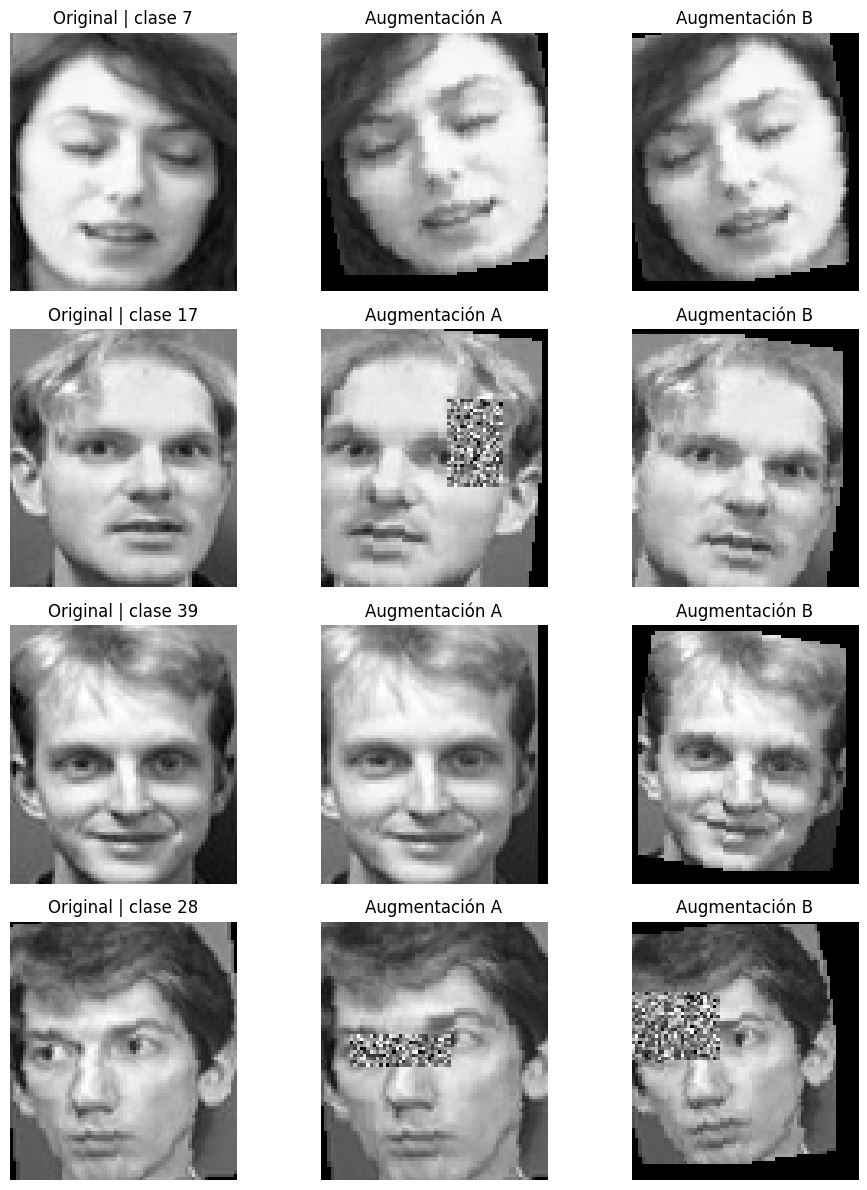

In [5]:
def denormalize(x, mean, std):
    return (x * std + mean).clamp(0, 1)

num_examples = 4
indices = torch.randperm(len(X_train_base))[:num_examples]

fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    img = X_train_base[idx]
    y = int(Y_train_base[idx])

    aug1 = train_transform(img.clone())
    aug2 = train_transform(img.clone())

    images = [img.squeeze(0).numpy(), denormalize(aug1, train_mean, train_std).squeeze(0).numpy(), denormalize(aug2, train_mean, train_std).squeeze(0).numpy()]
    titles = [f"Original | clase {y}", "Augmentación A", "Augmentación B"]

    for col, (im, t) in enumerate(zip(images, titles)):
        axes[row, col].imshow(im, cmap="gray")
        axes[row, col].set_title(t)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## ResNet Mejorada (residual + SE)

Se mantiene una estructura por bloques para facilitar modificaciones (stem, bloques residuales, etapas y clasificador).


In [6]:
def conv3x3(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)


def conv1x1(in_ch, out_ch, stride=1):
    return nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    def forward(self, x):
        w = self.pool(x)
        w = F.silu(self.fc1(w), inplace=True)
        w = torch.sigmoid(self.fc2(w))
        return x * w


class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop_prob=0.0):
        super().__init__()
        self.conv1 = conv3x3(in_ch, out_ch, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = conv3x3(out_ch, out_ch, stride=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        self.dropout = nn.Dropout2d(drop_prob) if drop_prob > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                conv1x1(in_ch, out_ch, stride=stride),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.silu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        out = self.dropout(out)

        out = out + identity
        out = F.silu(out, inplace=True)
        return out


class BetterResNet(nn.Module):
    def __init__(
        self,
        dim_out,
        base_channels=32,
        blocks=(2, 2, 2, 2),
        drop_prob=0.15,
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=None
    ):
        super().__init__()

        self.link = link_function
        self.loss = loss_function if loss_function is not None else nn.CrossEntropyLoss()

        c1 = base_channels
        c2 = c1 * 2
        c3 = c2 * 2
        c4 = c3 * 2

        self.stem = nn.Sequential(
            conv3x3(1, c1, stride=1),
            nn.BatchNorm2d(c1),
            nn.SiLU(inplace=True)
        )

        self.layer1 = self._make_layer(c1, c1, blocks[0], stride=1, drop_prob=drop_prob)
        self.layer2 = self._make_layer(c1, c2, blocks[1], stride=2, drop_prob=drop_prob)
        self.layer3 = self._make_layer(c2, c3, blocks[2], stride=2, drop_prob=drop_prob)
        self.layer4 = self._make_layer(c3, c4, blocks[3], stride=2, drop_prob=drop_prob)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head_dropout = nn.Dropout(p=drop_prob)
        self.fc = nn.Linear(c4, dim_out)

    @staticmethod
    def _make_layer(in_ch, out_ch, n_blocks, stride, drop_prob):
        layers = [ResidualSEBlock(in_ch, out_ch, stride=stride, drop_prob=drop_prob)]
        for _ in range(1, n_blocks):
            layers.append(ResidualSEBlock(out_ch, out_ch, stride=1, drop_prob=drop_prob))
        return nn.Sequential(*layers)

    def operator(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.head_dropout(x)
        x = self.fc(x)
        return x

    def forward_train(self, x, apply_link=False):
        self.train()
        y = self.operator(x)
        return self.link(y) if apply_link else y

    def forward_eval(self, x, apply_link=False):
        self.eval()
        y = self.operator(x)
        return self.link(y) if apply_link else y

    def compute_loss(self, t, y):
        return self.loss(y, t)


## Métricas y función de entrenamiento


In [7]:
def compute_metric_topk(dataloader, model, device, k=3):
    model.eval()
    correct = 0
    topk_correct = 0
    total = 0

    with torch.no_grad():
        for x, t in dataloader:
            x = x.to(device)
            t = t.to(device)
            logits = model.forward_eval(x, apply_link=False)

            pred = logits.argmax(dim=1)
            correct += (pred == t).sum().item()

            topk = torch.topk(logits, k=k, dim=1).indices
            topk_correct += topk.eq(t.view(-1, 1)).any(dim=1).sum().item()
            total += t.size(0)

    acc = correct / total
    topk_acc = topk_correct / total
    global_metric = 0.7 * acc + 0.3 * topk_acc
    return acc, topk_acc, global_metric


def create_loaders(batch_size, num_workers=0):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    train_eval_loader = DataLoader(train_dataset_eval, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, train_eval_loader, test_loader


def train_model(
    model,
    device,
    epochs,
    batch_size,
    lr,
    weight_decay,
    betas,
    eps,
    factor,
    patience,
    min_lr,
    grad_clip,
    trial=None
):
    train_loader, train_eval_loader, test_loader = create_loaders(batch_size=batch_size)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=betas,
        eps=eps
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )

    history = {
        "loss": [],
        "train_acc": [],
        "test_acc": [],
        "train_top3": [],
        "test_top3": [],
        "train_global": [],
        "test_global": [],
    }

    best_metric = -1.0
    best_epoch = -1
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for x, t in train_loader:
            x = x.to(device)
            t = t.to(device)

            optimizer.zero_grad(set_to_none=True)
            y = model.forward_train(x, apply_link=False)
            loss = model.compute_loss(t, y)
            loss.backward()

            if grad_clip is not None and grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            batch_size_real = t.size(0)
            running_loss += loss.item() * batch_size_real
            n_samples += batch_size_real

        epoch_loss = running_loss / max(1, n_samples)

        train_acc, train_top3, train_global = compute_metric_topk(train_eval_loader, model, device, k=3)
        test_acc, test_top3, test_global = compute_metric_topk(test_loader, model, device, k=3)

        scheduler.step(test_global)

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_top3"].append(train_top3)
        history["test_top3"].append(test_top3)
        history["train_global"].append(train_global)
        history["test_global"].append(test_global)

        if test_global > best_metric:
            best_metric = test_global
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if trial is not None:
            trial.report(test_global, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        print(
            f"Epoch {epoch+1:03d}/{epochs} | loss={epoch_loss:.4f} | "
            f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | "
            f"test_top3={test_top3:.4f} | test_global={test_global:.4f}"
        )

    print(f"Mejor época: {best_epoch} | Mejor global test: {best_metric:.4f}")

    model.load_state_dict(best_state)
    return history, best_epoch, best_metric


## Optuna: búsqueda de hiperparámetros


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def build_model_from_trial(trial):
    base_channels = trial.suggest_categorical("base_channels", [24, 32, 40])
    depth = trial.suggest_categorical("depth", ["2-2-2-2", "2-3-3-2"])
    drop_prob = trial.suggest_float("drop_prob", 0.08, 0.35)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.12)

    blocks = tuple(int(x) for x in depth.split("-"))
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    model = BetterResNet(
        dim_out=N_CLASSES,
        base_channels=base_channels,
        blocks=blocks,
        drop_prob=drop_prob,
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=loss_fn,
    )
    return model


def objective(trial):
    set_seed(42)

    lr = trial.suggest_float("lr", 8e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 3e-3, log=True)
    beta1 = trial.suggest_float("beta1", 0.85, 0.95)
    beta2 = trial.suggest_float("beta2", 0.97, 0.9995)
    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 24, 32, 48])

    factor = trial.suggest_categorical("factor", [0.3, 0.5, 0.7])
    patience = trial.suggest_int("patience", 8, 16)
    min_lr = trial.suggest_float("min_lr", 1e-6, 1e-4, log=True)
    grad_clip = trial.suggest_float("grad_clip", 0.5, 2.0)

    model = build_model_from_trial(trial).to(device)

    history, best_epoch, best_metric = train_model(
        model=model,
        device=device,
        epochs=120,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        betas=(beta1, beta2),
        eps=eps,
        factor=factor,
        patience=patience,
        min_lr=min_lr,
        grad_clip=grad_clip,
        trial=trial,
    )

    trial.set_user_attr("best_epoch", int(best_epoch))
    trial.set_user_attr("best_test_acc", float(history["test_acc"][best_epoch]))
    trial.set_user_attr("best_test_top3", float(history["test_top3"][best_epoch]))
    return float(best_metric)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)

study.optimize(objective, n_trials=30)

print("Mejor métrica global:", study.best_value)
print("Mejores hiperparámetros:", study.best_params)
print("Mejor época:", study.best_trial.user_attrs["best_epoch"])
print("Accuracy en esa época:", study.best_trial.user_attrs["best_test_acc"])
print("Top-3 en esa época:", study.best_trial.user_attrs["best_test_top3"])


[I 2026-04-21 09:39:07,547] A new study created in memory with name: no-name-483bcdab-d935-402f-ad2b-d28674687859


Device: cuda
Epoch 001/120 | loss=3.7082 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/120 | loss=3.6536 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 003/120 | loss=3.5237 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 004/120 | loss=3.4827 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 005/120 | loss=3.3955 | train_acc=0.0250 | test_acc=0.0375 | test_top3=0.0750 | test_global=0.0488
Epoch 006/120 | loss=3.3341 | train_acc=0.0312 | test_acc=0.0500 | test_top3=0.1375 | test_global=0.0762
Epoch 007/120 | loss=3.2673 | train_acc=0.0625 | test_acc=0.0875 | test_top3=0.1875 | test_global=0.1175
Epoch 008/120 | loss=3.1921 | train_acc=0.1062 | test_acc=0.1125 | test_top3=0.2750 | test_global=0.1613
Epoch 009/120 | loss=3.1595 | train_acc=0.1250 | test_acc=0.1375 | test_top3=0.2375 | test_global=0.1675
Epoch 010/120 | loss=3.0539 | train_acc=0.

[I 2026-04-21 09:40:02,676] Trial 0 finished with value: 0.9525 and parameters: {'lr': 0.0002671004403304731, 'weight_decay': 0.002021849951655674, 'beta1': 0.9231993941811405, 'beta2': 0.9876604252838126, 'eps': 2.0513382630874506e-09, 'batch_size': 32, 'factor': 0.7, 'patience': 15, 'min_lr': 2.6587543983272713e-06, 'grad_clip': 0.7727374508106509, 'base_channels': 40, 'depth': '2-2-2-2', 'drop_prob': 0.24520028157504242, 'label_smoothing': 0.016739263278245018}. Best is trial 0 with value: 0.9525.


Epoch 120/120 | loss=0.3217 | train_acc=1.0000 | test_acc=0.9250 | test_top3=0.9750 | test_global=0.9400
Mejor época: 94 | Mejor global test: 0.9525
Epoch 001/120 | loss=3.7083 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/120 | loss=3.6633 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 003/120 | loss=3.6591 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 004/120 | loss=3.6043 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 005/120 | loss=3.5129 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 006/120 | loss=3.4655 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 007/120 | loss=3.3868 | train_acc=0.0437 | test_acc=0.0250 | test_top3=0.1625 | test_global=0.0663
Epoch 008/120 | loss=3.3573 | train_acc=0.0875 | test_acc=0.0750 | test_top3=0.2125 | test_global=0.1162
Epoch 009/1

[I 2026-04-21 09:40:46,247] Trial 1 finished with value: 0.97 and parameters: {'lr': 0.00020487580805820204, 'weight_decay': 1.8788173075973946e-05, 'beta1': 0.8956069984217035, 'beta2': 0.993162690861094, 'eps': 2.5081156860452332e-09, 'batch_size': 48, 'factor': 0.7, 'patience': 16, 'min_lr': 4.138040112561016e-05, 'grad_clip': 0.9569206537600561, 'base_channels': 32, 'depth': '2-3-3-2', 'drop_prob': 0.08928490070110896, 'label_smoothing': 0.10911844824945384}. Best is trial 1 with value: 0.97.


...

Epoch 001/120 | loss=3.7064 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/120 | loss=3.5314 | train_acc=0.0500 | test_acc=0.0500 | test_top3=0.0750 | test_global=0.0575
Epoch 003/120 | loss=3.3973 | train_acc=0.0437 | test_acc=0.0125 | test_top3=0.0875 | test_global=0.0350
Epoch 004/120 | loss=3.2874 | train_acc=0.0813 | test_acc=0.0875 | test_top3=0.2250 | test_global=0.1288
Epoch 005/120 | loss=3.1921 | train_acc=0.1250 | test_acc=0.1125 | test_top3=0.2500 | test_global=0.1537
Epoch 006/120 | loss=3.1311 | train_acc=0.1688 | test_acc=0.1625 | test_top3=0.2875 | test_global=0.2000
Epoch 007/120 | loss=3.0108 | train_acc=0.2062 | test_acc=0.1875 | test_top3=0.3750 | test_global=0.2437
Epoch 008/120 | loss=2.8701 | train_acc=0.2875 | test_acc=0.2250 | test_top3=0.4250 | test_global=0.2850
Epoch 009/120 | loss=2.8278 | train_acc=0.2500 | test_acc=0.2750 | test_top3=0.4375 | test_global=0.3237
Epoch 010/120 | loss=2.7251 | train_acc=0.2562 | test_a

[I 2026-04-21 09:52:36,482] Trial 28 pruned. 


Epoch 001/120 | loss=3.7070 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/120 | loss=3.4962 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0875 | test_global=0.0437
Epoch 003/120 | loss=3.3127 | train_acc=0.0250 | test_acc=0.0375 | test_top3=0.1000 | test_global=0.0562
Epoch 004/120 | loss=3.1895 | train_acc=0.0563 | test_acc=0.0500 | test_top3=0.1500 | test_global=0.0800
Epoch 005/120 | loss=3.0657 | train_acc=0.1500 | test_acc=0.1250 | test_top3=0.2750 | test_global=0.1700
Epoch 006/120 | loss=2.9557 | train_acc=0.2188 | test_acc=0.2000 | test_top3=0.4250 | test_global=0.2675
Epoch 007/120 | loss=2.8099 | train_acc=0.2437 | test_acc=0.2000 | test_top3=0.4750 | test_global=0.2825
Epoch 008/120 | loss=2.7007 | train_acc=0.3187 | test_acc=0.2125 | test_top3=0.4625 | test_global=0.2875
Epoch 009/120 | loss=2.5689 | train_acc=0.3312 | test_acc=0.2500 | test_top3=0.5125 | test_global=0.3287
Epoch 010/120 | loss=2.5072 | train_acc=0.3750 | test_a

[I 2026-04-21 09:52:48,750] Trial 29 pruned. 


Mejor métrica global: 0.9824999999999999
Mejores hiperparámetros: {'lr': 0.000601099948020469, 'weight_decay': 5.6534054405270875e-05, 'beta1': 0.9370127373876532, 'beta2': 0.9946771426881929, 'eps': 7.465077851171261e-09, 'batch_size': 16, 'factor': 0.3, 'patience': 12, 'min_lr': 5.364968938694532e-05, 'grad_clip': 0.7061038628244418, 'base_channels': 40, 'depth': '2-2-2-2', 'drop_prob': 0.0803723467290252, 'label_smoothing': 0.011152233168652124}
Mejor época: 99
Accuracy en esa época: 0.975
Top-3 en esa época: 1.0


## Reentrenamiento final con los mejores hiperparámetros


In [9]:
best = study.best_params
print("Hiperparámetros óptimos:", best)

blocks = tuple(int(x) for x in best["depth"].split("-"))
final_loss = nn.CrossEntropyLoss(label_smoothing=best["label_smoothing"])

final_model = BetterResNet(
    dim_out=N_CLASSES,
    base_channels=best["base_channels"],
    blocks=blocks,
    drop_prob=best["drop_prob"],
    link_function=lambda x: torch.softmax(x, dim=1),
    loss_function=final_loss,
).to(device)

final_history, final_best_epoch, final_best_metric = train_model(
    model=final_model,
    device=device,
    epochs=220,
    batch_size=best["batch_size"],
    lr=best["lr"],
    weight_decay=best["weight_decay"],
    betas=(best["beta1"], best["beta2"]),
    eps=best["eps"],
    factor=best["factor"],
    patience=best["patience"],
    min_lr=best["min_lr"],
    grad_clip=best["grad_clip"],
    trial=None,
)


Hiperparámetros óptimos: {'lr': 0.000601099948020469, 'weight_decay': 5.6534054405270875e-05, 'beta1': 0.9370127373876532, 'beta2': 0.9946771426881929, 'eps': 7.465077851171261e-09, 'batch_size': 16, 'factor': 0.3, 'patience': 12, 'min_lr': 5.364968938694532e-05, 'grad_clip': 0.7061038628244418, 'base_channels': 40, 'depth': '2-2-2-2', 'drop_prob': 0.0803723467290252, 'label_smoothing': 0.011152233168652124}
Epoch 001/220 | loss=3.7471 | train_acc=0.0250 | test_acc=0.0250 | test_top3=0.0750 | test_global=0.0400
Epoch 002/220 | loss=3.4677 | train_acc=0.0563 | test_acc=0.0500 | test_top3=0.1500 | test_global=0.0800
Epoch 003/220 | loss=3.2742 | train_acc=0.0625 | test_acc=0.0500 | test_top3=0.1375 | test_global=0.0762
Epoch 004/220 | loss=3.1249 | train_acc=0.1125 | test_acc=0.1000 | test_top3=0.2375 | test_global=0.1412
Epoch 005/220 | loss=2.9650 | train_acc=0.1500 | test_acc=0.1125 | test_top3=0.2625 | test_global=0.1575
Epoch 006/220 | loss=2.8514 | train_acc=0.1938 | test_acc=0.125

## Resumen y gráficas


Mejor época final: 203
Mejor test global final: 0.9825
Accuracy test en mejor época: 0.9750
Top-3 test en mejor época: 1.0000


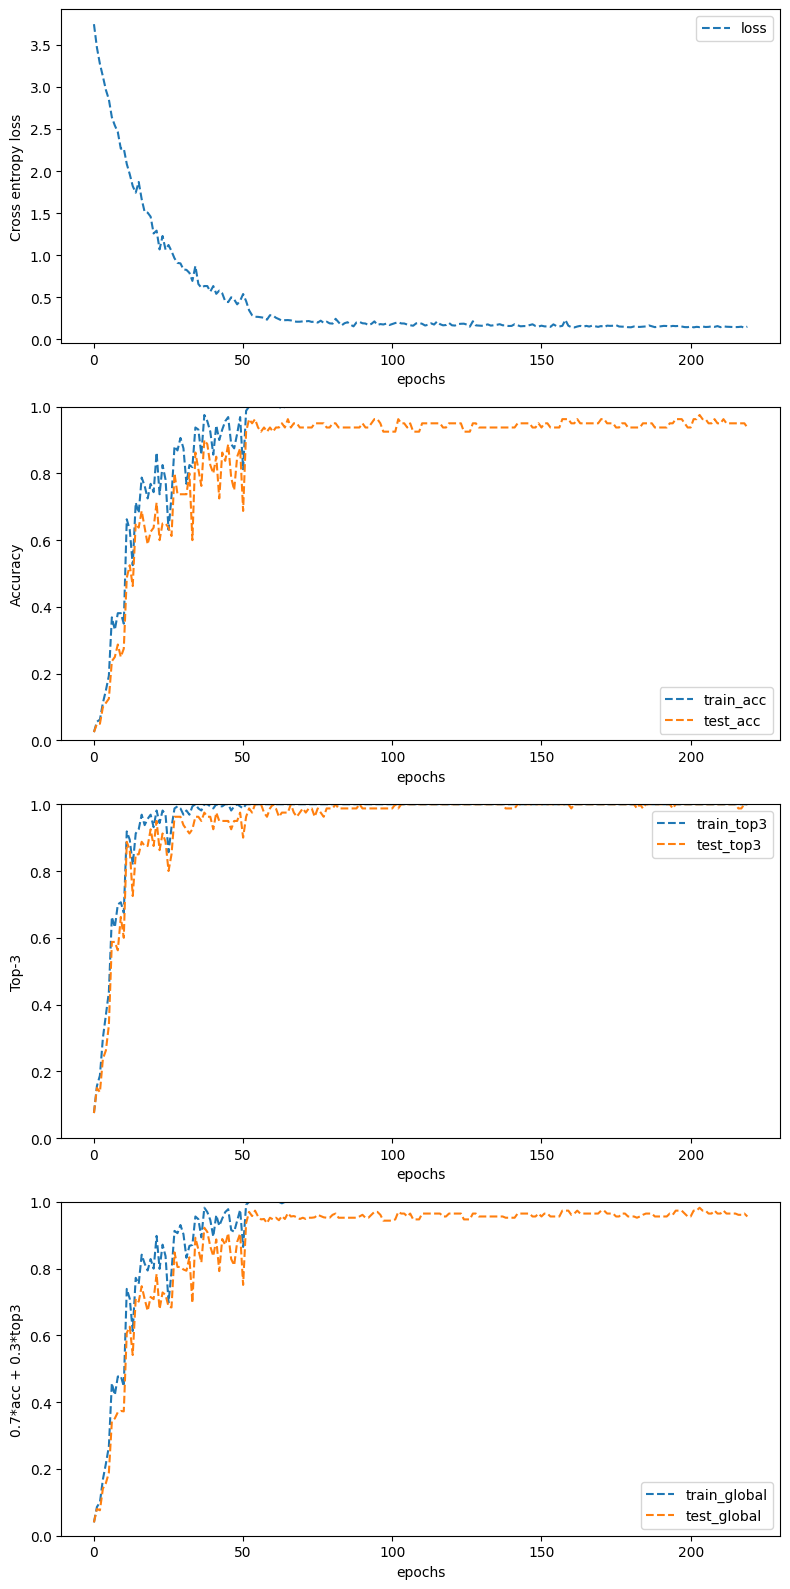

In [10]:
print(f"Mejor época final: {final_best_epoch}")
print(f"Mejor test global final: {final_best_metric:.4f}")
print(f"Accuracy test en mejor época: {final_history['test_acc'][final_best_epoch]:.4f}")
print(f"Top-3 test en mejor época: {final_history['test_top3'][final_best_epoch]:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 16))

ax1.plot(final_history['loss'], linestyle='--')
ax1.set_ylabel('Cross entropy loss')
ax1.set_xlabel('epochs')
ax1.legend(['loss'])

ax2.plot(final_history['train_acc'], linestyle='--')
ax2.plot(final_history['test_acc'], linestyle='--')
ax2.set_ylim([0.0, 1.0])
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('epochs')
ax2.legend(['train_acc', 'test_acc'])

ax3.plot(final_history['train_top3'], linestyle='--')
ax3.plot(final_history['test_top3'], linestyle='--')
ax3.set_ylim([0.0, 1.0])
ax3.set_ylabel('Top-3')
ax3.set_xlabel('epochs')
ax3.legend(['train_top3', 'test_top3'])

ax4.plot(final_history['train_global'], linestyle='--')
ax4.plot(final_history['test_global'], linestyle='--')
ax4.set_ylim([0.0, 1.0])
ax4.set_ylabel('0.7*acc + 0.3*top3')
ax4.set_xlabel('epochs')
ax4.legend(['train_global', 'test_global'])

plt.tight_layout()
plt.show()


## Matriz de probabilidades sobre test


In [11]:
_, _, test_loader = create_loaders(batch_size=32)

n_test = len(test_dataset)
matriz_probs = torch.zeros((n_test, N_CLASSES), dtype=torch.float32)

final_model.eval()
index = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        logits = final_model.forward_eval(x, apply_link=False)
        probs = torch.softmax(logits, dim=1).cpu()

        b = probs.size(0)
        matriz_probs[index:index + b] = probs
        index += b

print("Shape matriz_probs:", matriz_probs.shape)
print(matriz_probs)

matriz_probs_np = matriz_probs.numpy()
print("Shape matriz_probs_np:", matriz_probs_np.shape)


Shape matriz_probs: torch.Size([80, 40])
tensor([[3.8361e-07, 1.4931e-05, 1.4870e-05,  ..., 4.7517e-06, 2.0734e-05,
         1.4368e-06],
        [1.8943e-06, 1.2120e-04, 6.2932e-06,  ..., 5.6313e-06, 3.0804e-04,
         5.9372e-06],
        [1.5139e-05, 4.1678e-05, 3.0805e-05,  ..., 2.6278e-05, 5.3216e-04,
         1.8027e-05],
        ...,
        [4.1196e-07, 7.6940e-07, 2.5432e-06,  ..., 2.8643e-05, 4.4943e-05,
         1.0459e-08],
        [3.4537e-07, 6.6214e-07, 9.9399e-01,  ..., 1.9288e-03, 3.3338e-05,
         2.2067e-05],
        [1.7464e-07, 2.7865e-06, 6.8772e-07,  ..., 6.6413e-05, 1.4363e-06,
         9.6832e-08]])
Shape matriz_probs_np: (80, 40)
